# Study 9: response histograms per test feature

Raw prevalence-rating distributions for the 15 test features, to eyeball the shape of the data
(bimodality, pile-ups at 0/50/100, etc.) before any modeling.

- **Aggregate**: all participants pooled, one panel per feature.
- **By condition**: split by which generic utterances the participant saw — `diet`, `personality`,
  `physical`, or `heterogeneous` (a mix). Features are grouped into rows by trait type, so the
  "matching" condition (e.g. the `diet` condition for a diet feature) lines up with its row.

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
COLS  = list(CSV_TO_FEATURE.keys())
NAMES = list(CSV_TO_FEATURE.values())
# trait group from the column prefix (rows of the plot grid)
GROUP = {'diet':'diet', 'pers':'personality', 'phys':'physical'}
feat_group = [GROUP[c.split('_')[0]] for c in COLS]

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
header = rows[0]; data = rows[3:]
col_idx  = [header.index(c) for c in COLS]
cond_idx = header.index('condition')

R, cond = [], []
for r in data:
    try:
        vals = [int(r[i]) for i in col_idx]   # 0-100 slider
    except (ValueError, IndexError):
        continue
    R.append(vals); cond.append(r[cond_idx])
R = np.array(R); cond = np.array(cond)
N, J = R.shape
CONDITIONS = ['diet', 'personality', 'physical', 'heterogeneous']
print(f"{N} participants x {J} features")
print("condition counts:", {c: int((cond==c).sum()) for c in CONDITIONS})

402 participants x 15 features
condition counts: {'diet': 101, 'personality': 101, 'physical': 101, 'heterogeneous': 99}


## Aggregate (all participants)

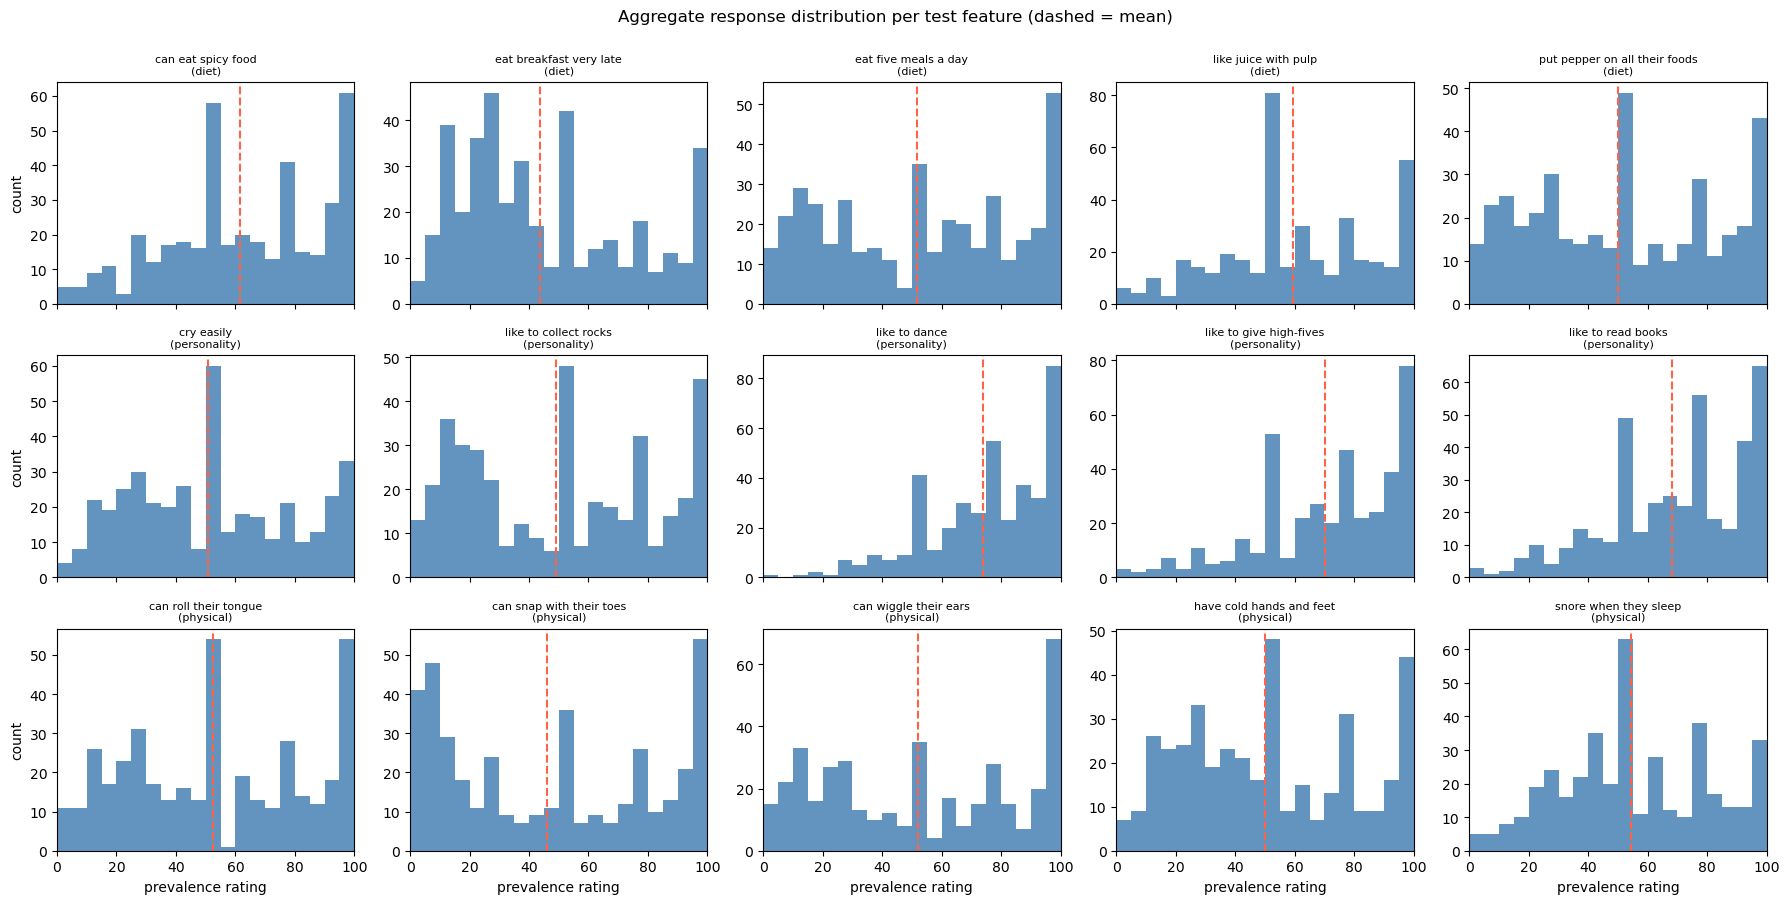

In [2]:
bins = np.arange(0, 105, 5)   # 0-100 slider, width-5 bins
fig, axes = plt.subplots(3, 5, figsize=(18, 9), sharex=True)
for j, ax in enumerate(axes.flat):
    ax.hist(R[:, j], bins=bins, color='steelblue', alpha=0.85)
    ax.axvline(R[:, j].mean(), color='tomato', lw=1.5, ls='--')
    ax.set_title(f"{NAMES[j]}\n({feat_group[j]})", fontsize=8)
    ax.set_xlim(0, 100)
for ax in axes[-1]:
    ax.set_xlabel('prevalence rating')
for ax in axes[:, 0]:
    ax.set_ylabel('count')
fig.suptitle('Aggregate response distribution per test feature (dashed = mean)', y=1.00)
plt.tight_layout(); plt.show()

## By condition

Small multiples: **one row per feature, one column per condition**. The y-axis is shared within
each feature's row, so the four conditions are directly comparable in height. The shaded panel in
each row marks the condition whose generic utterances matched that feature's trait type (e.g. the
`diet` condition for a diet feature). Dashed line = that panel's mean.

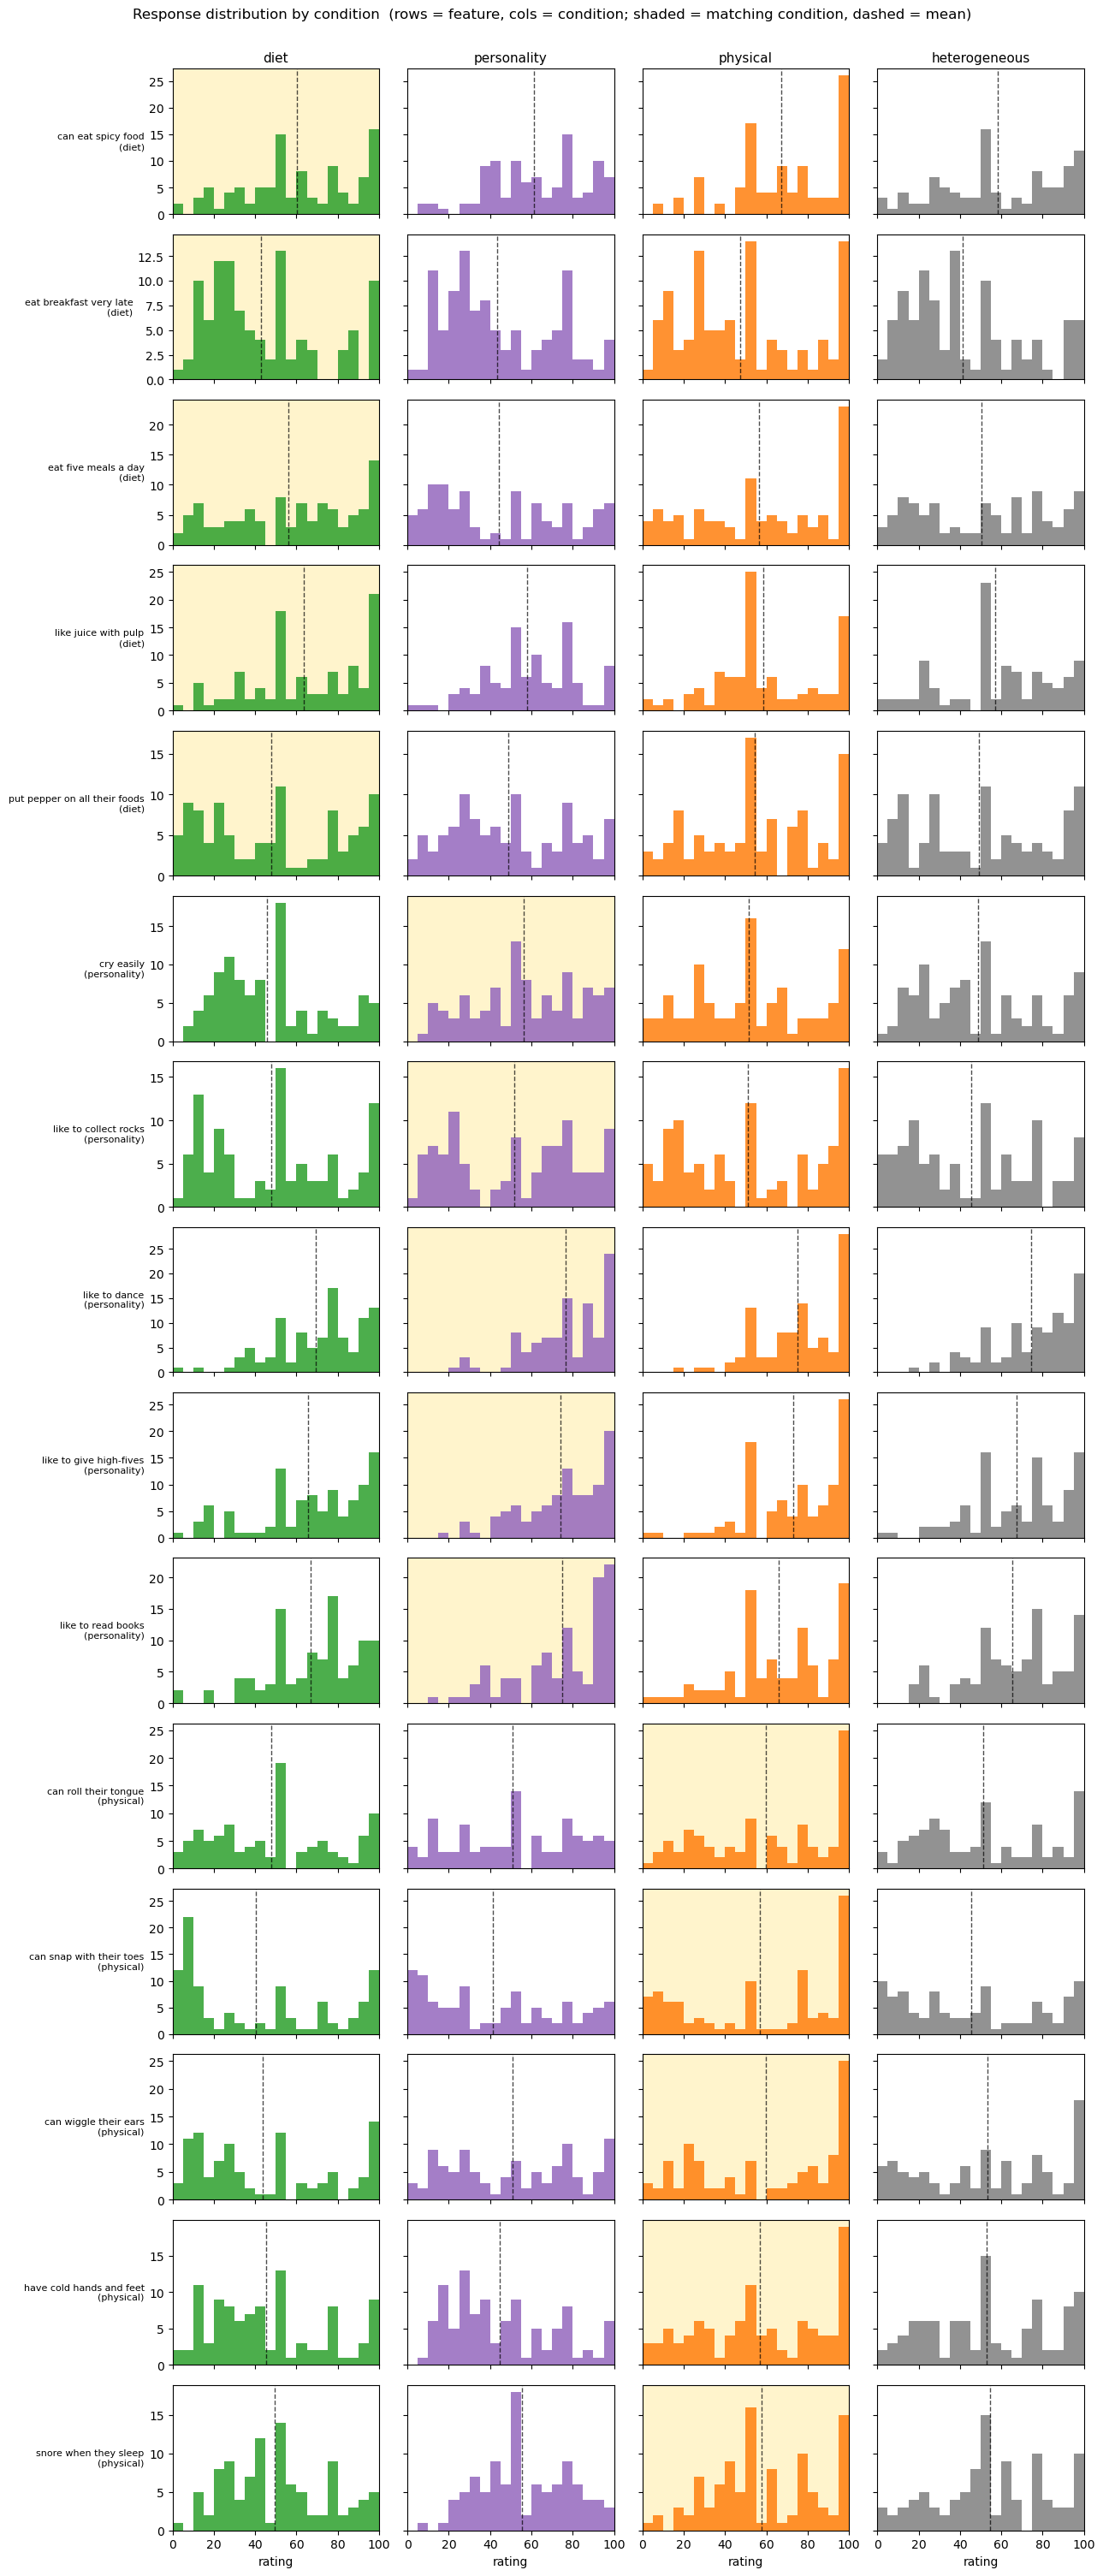

In [5]:
cond_colors = {'diet':'tab:green', 'personality':'tab:purple',
               'physical':'tab:orange', 'heterogeneous':'tab:gray'}

# Small multiples: one row per feature, one column per condition.
# sharey='row' makes the 4 conditions directly comparable in height within each feature.
fig, axes = plt.subplots(J, len(CONDITIONS), figsize=(13, 2.0 * J),
                         sharex=True, sharey='row')
for j in range(J):
    for ci, c in enumerate(CONDITIONS):
        ax   = axes[j, ci]
        vals = R[cond == c, j]
        ax.hist(vals, bins=bins, color=cond_colors[c], alpha=0.85)
        ax.axvline(vals.mean(), color='k', lw=1, ls='--', alpha=0.7)
        ax.set_xlim(0, 100)
        if c == feat_group[j]:                     # matching condition for this feature
            ax.set_facecolor('#fff4cc')
        if j == 0:
            ax.set_title(c, fontsize=11)
        if ci == 0:
            ax.set_ylabel(f"{NAMES[j]}\n({feat_group[j]})", rotation=0,
                          ha='right', va='center', fontsize=8)
        if j == J - 1:
            ax.set_xlabel('rating')
fig.suptitle('Response distribution by condition  (rows = feature, cols = condition; '
             'shaded = matching condition, dashed = mean)', y=1.002, fontsize=12)
plt.tight_layout(); plt.show()

## By condition — means (compact summary)

Same data as above, condensed: mean rating per feature x condition. Lets you see whether seeing
generic utterances about a trait type shifts prevalence judgments for features of that type.

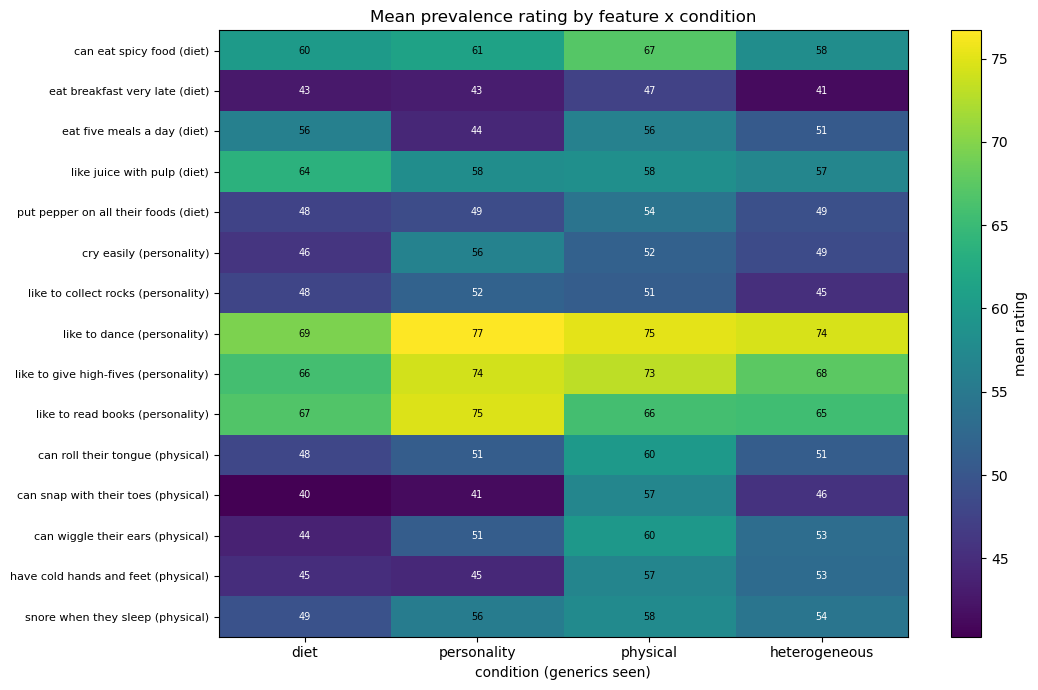

In [4]:
means = np.array([[R[cond==c, j].mean() for c in CONDITIONS] for j in range(J)])  # (J, 4)

fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(means, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(CONDITIONS))); ax.set_xticklabels(CONDITIONS)
ax.set_yticks(range(J)); ax.set_yticklabels([f"{NAMES[j]} ({feat_group[j]})" for j in range(J)], fontsize=8)
ax.set_xlabel('condition (generics seen)'); ax.set_title('Mean prevalence rating by feature x condition')
for j in range(J):
    for ci in range(len(CONDITIONS)):
        ax.text(ci, j, f"{means[j,ci]:.0f}", ha='center', va='center',
                fontsize=7, color='white' if means[j,ci] < means.mean() else 'black')
plt.colorbar(im, ax=ax, label='mean rating')
plt.tight_layout(); plt.show()